In [1]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split
from sklearn.model_selection import train_test_split

#import sys
#!{sys.executable} -m pip install tensorflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_full shape: (60000, 28, 28)
y_train_full shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
print("Unika labels:", np.unique(y_train_full))

print("Minsta pixelvärde:", X_train_full.min())
print("Största pixelvärde:", X_train_full.max())

Unika labels: [0 1 2 3 4 5 6 7 8 9]
Minsta pixelvärde: 0
Största pixelvärde: 255


In [4]:
# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


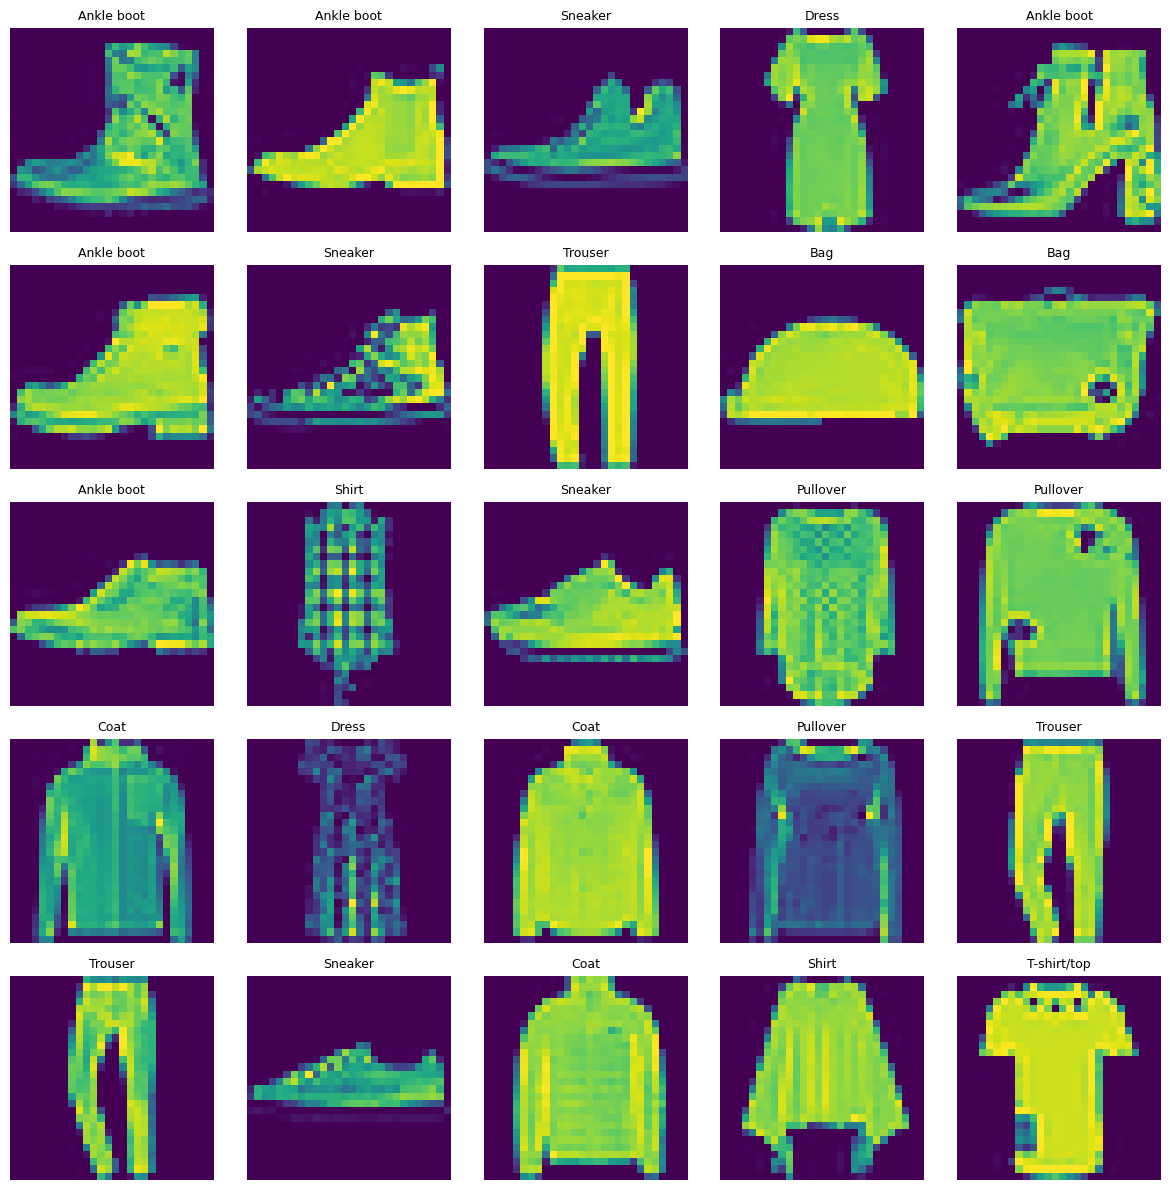

In [5]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

## Dataförståelse

Datasetet innehåller totalt **70 000 bilder**, där `X_train_full` består av **60 000 träningsbilder** och `X_test` av **10 000 testbilder**. Varje bild har storleken **28 × 28 pixlar**, och tillhörande etiketter finns i `y_train_full` och `y_test`.

Datasetet innehåller 10 klasser:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot

Varje klass innehåller **6000 bilder**, vilket innebär att datasetet är **balanserat** utan över- eller underrepresenterade klasser.

Baserat på de första 25 bilderna som visualiserades verkar även etiketteringen vara korrekt, då bilderna överensstämde med sina respektive klasser.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("X_train", X_train.shape)
print("X_val", X_val.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [7]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


print("Minsta värde efter normalisering:", X_train.min())
print("Största värde efter normalisering:", X_train.max())

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape efter kanal-dimension:", X_train.shape)
print("X_val shape efter kanal-dimension:", X_val.shape)
print("X_test shape efter kanal-dimension:", X_test.shape)

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0
X_train shape efter kanal-dimension: (54000, 28, 28, 1)
X_val shape efter kanal-dimension: (6000, 28, 28, 1)
X_test shape efter kanal-dimension: (10000, 28, 28, 1)


## Förberedelse av data


### Dela upp träningsdata i träning och validering
Vi delar upp `X_train_full` och `y_train_full` i:

- **Träningsdata (X_train, y_train)**
- **Valideringsdata (X_val, y_val)**

Vi använder:
- 10% av datan som valideringsset (`test_size=0.10`)
- `stratify=y_train_full` för att behålla samma klassfördelning i båda delarna
- `random_state=42` för att få samma uppdelning varje gång

### Normalisering av pixelvärden
Vi konverterar bilderna till `float32` och skalar pixelvärden från:

- **0–255 → 0–1**

Detta görs för:
- snabbare och stabilare träning
- bättre numerisk stabilitet i modellen

Vi verifierar även att:
- minsta värde ≈ 0
- största värde ≈ 1

### Lägga till kanal-dimension
Eftersom bilderna är gråskaliga lägger vi till en extra dimension:

- Från: `(28, 28)`
- Till: `(28, 28, 1)`

Detta krävs för att neurala nätverk (t.ex. CNN) ska kunna behandla bilderna korrekt.

In [8]:
model = keras.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

### Modellskapande 
Vi bygger en sekventiell modell med följande lager:

- Conv2D (32 filter, 3×3) — extraherar lokala mönster (kanter, texturer)
- MaxPooling2D (2×2) — minskar dimensionerna och behåller viktigaste informationen
- Conv2D (64 filter, 3×3) — extraherar mer komplexa mönster
- MaxPooling2D (2×2) — ytterligare dimensionsreduktion
- Flatten — gör om 2D-features till en 1D-vektor
- Dense (64 neuroner, ReLU) — lär sig kombinationer av features
- Dense (10 neuroner, softmax) — ger sannolikheter för varje klass (0–9)

Vi använder padding="same" för att behålla bildens dimensioner genom konvolutionslagren.

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

### Kompilering
Modellen kompileras med:

- Optimizer: Adam(learning_rate=0.001) -- adaptiv inlärning
- Loss: SparseCategoricalCrossentropy -- lämplig för flerklass-klassificering
- Metric: Accuracy -- andel korrekta klassificeringar

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8349 - loss: 0.4604 - val_accuracy: 0.8712 - val_loss: 0.3573
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8923 - loss: 0.3011 - val_accuracy: 0.8910 - val_loss: 0.3042
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9085 - loss: 0.2561 - val_accuracy: 0.8942 - val_loss: 0.2951
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9186 - loss: 0.2255 - val_accuracy: 0.8973 - val_loss: 0.2832
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9269 - loss: 0.2012 - val_accuracy: 0.9017 - val_loss: 0.2750


### Träning
Modellen tränas med:

- 5 epoker -- varje epok går igenom hela träningsdatan en gång
- Batch size 64 -- uppdaterar vikterna efter varje batch
- Valideringsdata -- utvärderar modellen på osedd data efter varje epok

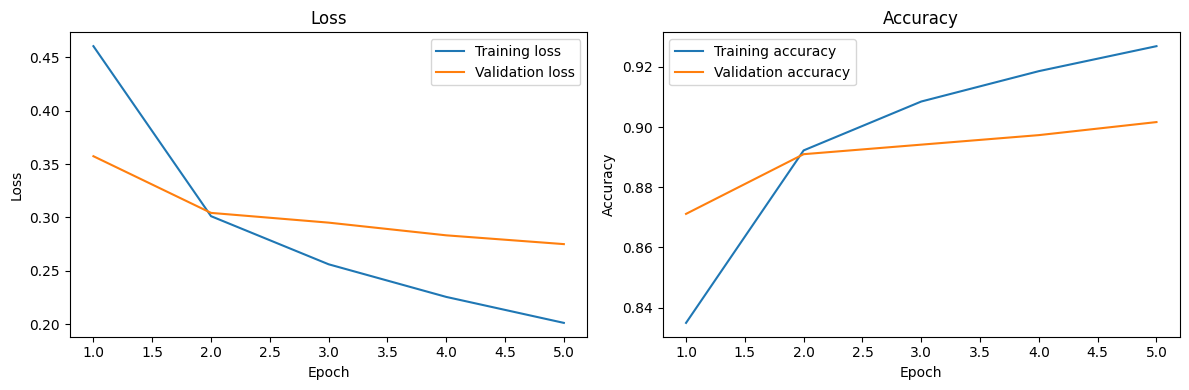

In [11]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) +1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

### Visualisering av träningshistorik
Vi plottar:

- Loss (träning vs validering) -- visar om modellen överanpassar
- Accuracy (träning vs validering) -- visar hur väl modellen generaliserar

### Test och förbättring av modellen

- Vi testar olika förändringar i modellen för att se om resultatet förbättras.

- Vi testar fler neuroner, fler filter och ändrad learning rate.


In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_baseline = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9348 - loss: 0.1803 - val_accuracy: 0.9038 - val_loss: 0.2720
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9440 - loss: 0.1591 - val_accuracy: 0.9042 - val_loss: 0.2869
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9502 - loss: 0.1403 - val_accuracy: 0.9007 - val_loss: 0.3066
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9562 - loss: 0.1240 - val_accuracy: 0.9050 - val_loss: 0.2988
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9623 - loss: 0.1096 - val_accuracy: 0.9063 - val_loss: 0.3128
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9675 - loss: 0.0961 - val_accuracy: 0.9165 - val_loss: 0.2932
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9700 - loss: 0.0870 - val_accuracy: 0.9120 - val_loss: 0.3164
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9731 - loss: 0.0802 - val_accuracy: 0.

### Baseline-modell

Först tränas originalmodellen för att få ett resultat att jämföra med.

In [13]:
baseline_test_loss, baseline_test_accuracy = model.evaluate(X_test, y_test)

print("Baseline test loss:", baseline_test_loss)
print("Baseline test accuracy:", baseline_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8784 - loss: 0.5639   
Baseline test loss: 0.563906192779541
Baseline test accuracy: 0.8784000277519226


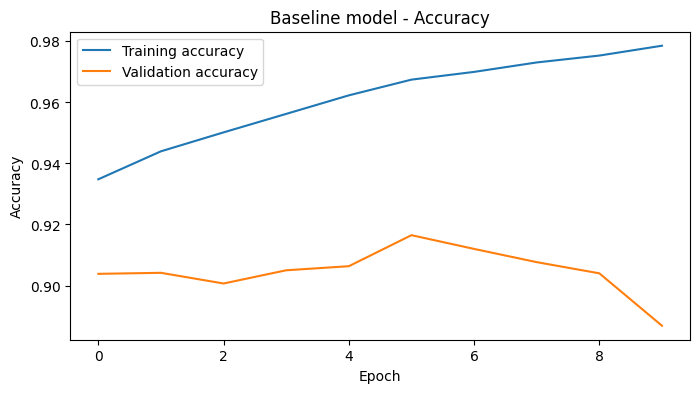

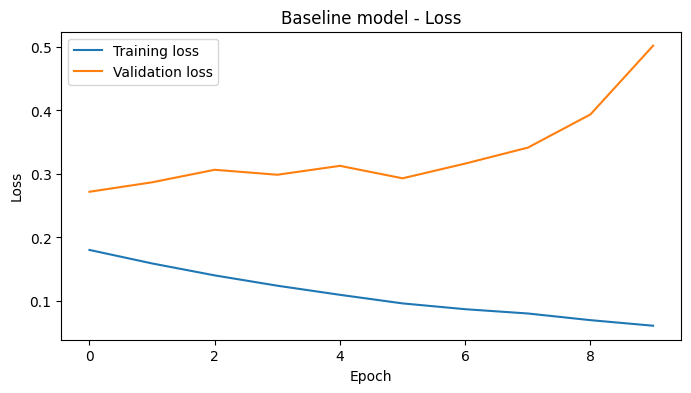

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline model")

### Testar med fler neuroner

ökar antalet neuroner i Dense-lagret från 64 till 128.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8388 - loss: 0.4472 - val_accuracy: 0.8813 - val_loss: 0.3322
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8945 - loss: 0.2946 - val_accuracy: 0.8968 - val_loss: 0.2886
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9096 - loss: 0.2467 - val_accuracy: 0.9020 - val_loss: 0.2721
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9219 - loss: 0.2130 - val_accuracy: 0.9092 - val_loss: 0.2536
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9336 - loss: 0.1848 - val_accuracy: 0.9133 - val_loss: 0.2476
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9431 - loss: 0.1604 - val_accuracy: 0.9053 - val_loss: 0.2752
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9509 - loss: 0.1374 - val_accuracy: 0.9057 - val_loss: 0.2885
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9585 - loss: 0.1176 - val_accuracy: 0.

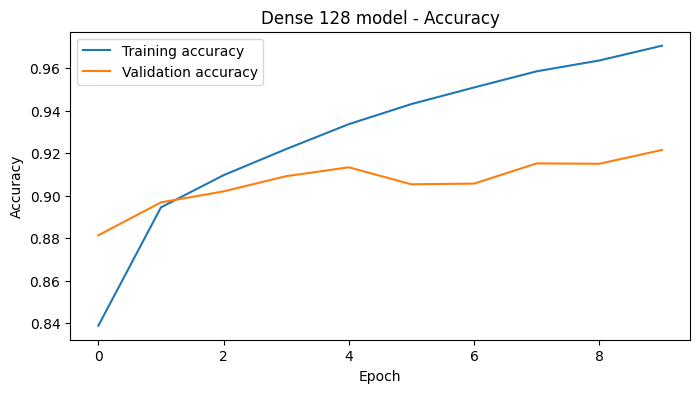

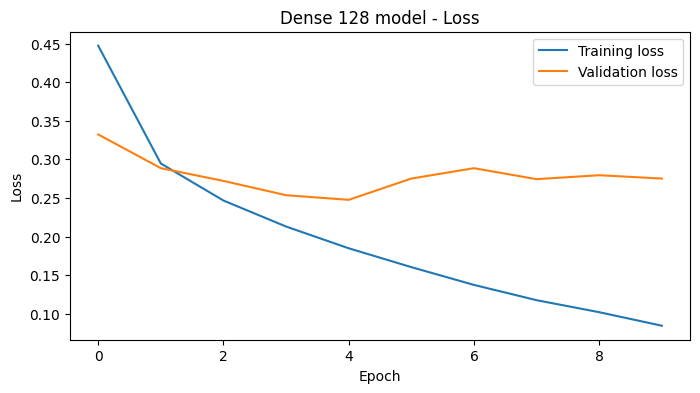

In [15]:
model_dense_128 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_dense_128.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_dense_128 = model_dense_128.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

dense_128_test_loss, dense_128_test_accuracy = model_dense_128.evaluate(X_test, y_test)

print("Dense 128 test loss:", dense_128_test_loss)
print("Dense 128 test accuracy:", dense_128_test_accuracy)

plot_history(history_dense_128, "Dense 128 model")

### Testar med fler filter

testar med fler filter i Conv2D-lagren.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8414 - loss: 0.4393 - val_accuracy: 0.8842 - val_loss: 0.3095
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8971 - loss: 0.2856 - val_accuracy: 0.9017 - val_loss: 0.2662
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9146 - loss: 0.2373 - val_accuracy: 0.9060 - val_loss: 0.2548
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9258 - loss: 0.2050 - val_accuracy: 0.9123 - val_loss: 0.2447
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9361 - loss: 0.1774 - val_accuracy: 0.9160 - val_loss: 0.2433
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9454 - loss: 0.1521 - val_accuracy: 0.9170 - val_loss: 0.2470
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9536 - loss: 0.1292 - val_accuracy: 0.9147 - val_loss: 0.2763
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9625 - loss: 0.1086 - val_accuracy: 0.

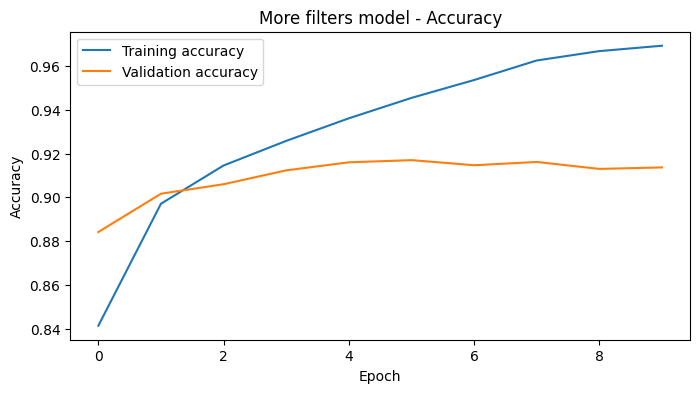

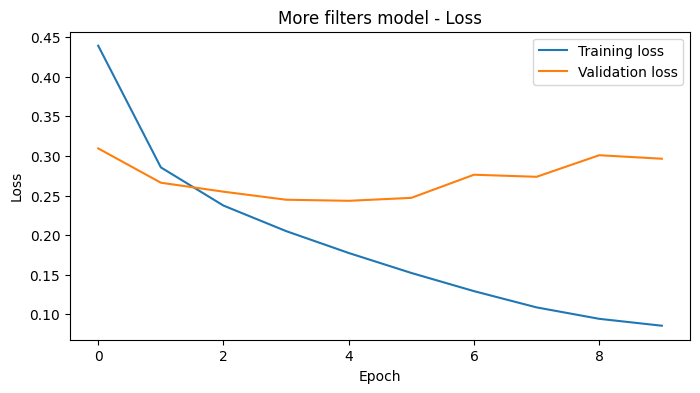

In [16]:
model_more_filters = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_more_filters.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_more_filters = model_more_filters.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

more_filters_test_loss, more_filters_test_accuracy = model_more_filters.evaluate(X_test, y_test)

print("More filters test loss:", more_filters_test_loss)
print("More filters test accuracy:", more_filters_test_accuracy)

plot_history(history_more_filters, "More filters model")

### Testar med lägre learning rate

testar med en lägre learning rate.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8151 - loss: 0.5192 - val_accuracy: 0.8532 - val_loss: 0.3889
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8780 - loss: 0.3416 - val_accuracy: 0.8788 - val_loss: 0.3316
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8922 - loss: 0.2976 - val_accuracy: 0.8895 - val_loss: 0.2986
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9024 - loss: 0.2693 - val_accuracy: 0.8973 - val_loss: 0.2742
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9105 - loss: 0.2473 - val_accuracy: 0.9037 - val_loss: 0.2590
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9166 - loss: 0.2284 - val_accuracy: 0.9073 - val_loss: 0.2521
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9229 - loss: 0.2115 - val_accuracy: 0.9125 - val_loss: 0.2424
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9288 - loss: 0.1958 - val_accuracy: 0.

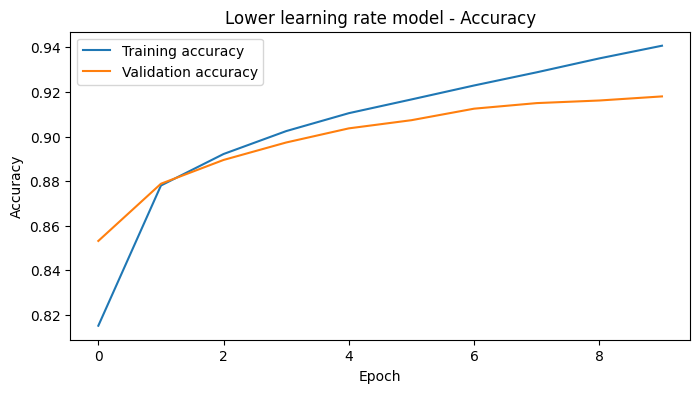

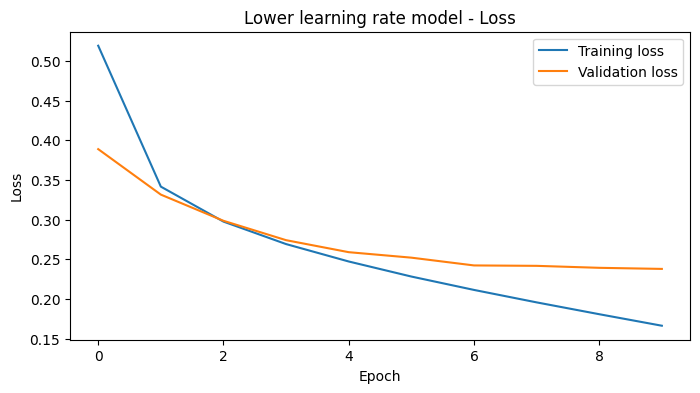

In [17]:
model_lower_lr = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model_lower_lr.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lower_lr = model_lower_lr.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

lower_lr_test_loss, lower_lr_test_accuracy = model_lower_lr.evaluate(X_test, y_test)

print("Lower learning rate test loss:", lower_lr_test_loss)
print("Lower learning rate test accuracy:", lower_lr_test_accuracy)

plot_history(history_lower_lr, "Lower learning rate model")

### Jämförelse av modellerna

jämför modellerna med test accuracy och test loss.

In [18]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dense 128",
        "More filters",
        "Lower learning rate"
    ],
    "Test loss": [
        baseline_test_loss,
        dense_128_test_loss,
        more_filters_test_loss,
        lower_lr_test_loss
    ],
    "Test accuracy": [
        baseline_test_accuracy,
        dense_128_test_accuracy,
        more_filters_test_accuracy,
        lower_lr_test_accuracy
    ]
})

results

,Model,Test loss,Test accuracy
0,Baseline,0.563906,0.8784
1,Dense 128,0.338473,0.9095
2,More filters,0.338595,0.9061
3,Lower learning rate,0.272283,0.9071


### Analys

Förändringar i modellen påverkade resultatet på olika sätt.

Modellen med lägre learning rate presterade bäst och fick högst test accuracy samt lägst test loss.

Det tyder på att en lägre learning rate gjorde träningen stabilare och hjälpte modellen att lära sig bättre.

## Fördjupning: Regularisering

Efter att vi testat olika modellförändringar såg vi att mer komplexa modeller kunde ge högre training accuracy, men inte alltid bättre generalisering. Därför testar vi regularisering.

Syftet med regularisering är att minska risken för overfitting, alltså att modellen lär sig träningsdatan för bra men presterar sämre på ny/osedd data.

Vi testar tre metoder:
- Dropout
- Early stopping
- L2-regularisering

## Dropout

Dropout innebär att modellen slumpmässigt stänger av en viss andel neuroner under träningen. Detta gör att modellen inte kan förlita sig för mycket på enskilda neuroner och kan därför minska overfitting.

Vi testar dropout med 0.3 efter Dense-lagret.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7806 - loss: 0.6206 - val_accuracy: 0.8717 - val_loss: 0.3621
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8607 - loss: 0.3928 - val_accuracy: 0.8958 - val_loss: 0.3004
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8798 - loss: 0.3400 - val_accuracy: 0.9033 - val_loss: 0.2744
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8891 - loss: 0.3103 - val_accuracy: 0.9032 - val_loss: 0.2634
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8962 - loss: 0.2870 - val_accuracy: 0.9120 - val_loss: 0.2458
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9027 - loss: 0.2694 - val_accuracy: 0.9148 - val_loss: 0.2340
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9081 - loss: 0.2526 - val_accuracy: 0.9160 - val_loss: 0.2311
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9116 - loss: 0.2386 - val_accuracy: 0.

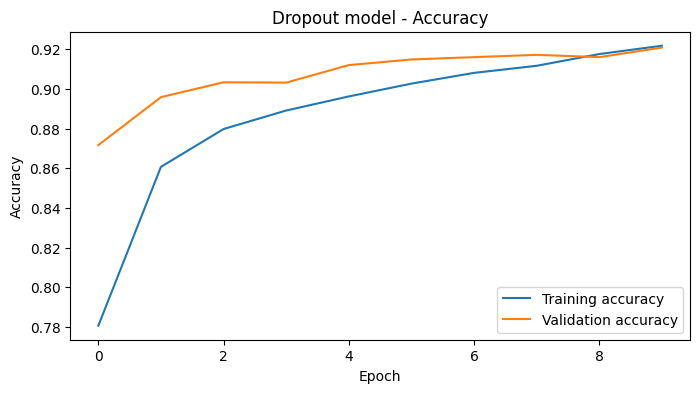

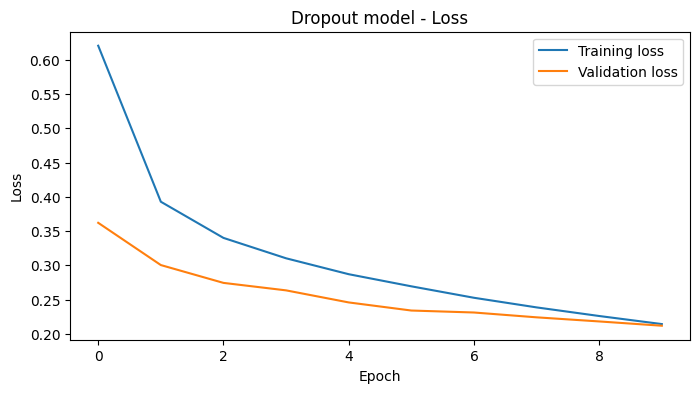

In [19]:
# Model with dropout
# Samma grundstruktur som tidigare modeller, men med en Dropout-lager efter Dense-lagret.
model_dropout = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

# Vi använder samma learning rate som modellen med lägre learning rate, eftersom Dropout kan göra att modellen lär sig långsammare och därmed kan gynnas av en lägre learning rate.
model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Vi tränar modellen och använder valideringsdata för att följa generalisering, med samma antal epoch och batch size som tidigare modeller för att göra resultaten mer jämförbara.
history_dropout = model_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data.
dropout_test_loss, dropout_test_accuracy = model_dropout.evaluate(X_test, y_test)

print("Dropout test loss:", dropout_test_loss)
print("Dropout test accuracy:", dropout_test_accuracy)

# Plottar tränings och valideringskurvor
plot_history(history_dropout, "Dropout model")

### Tolkning av Dropout resultat

Dropout gav en test accuracy på ca **0.9116** och test loss på ca **0.2459**.

Jämfört med baseline och flera av de mer komplexa modellerna blev resultatet stabilt. Training accuracy blev något lägre än i modellerna utan regularisering, vilket är ett förväntat resultat eftersom dropout gör träningen svårare.

Samtidigt blev validation accuracy hög och validation loss höll sig relativt stabil. Det tyder på att modellen generaliserade bättre och inte förlitade sig lika mycket på enskilda neuroner.

### Early stopping

Early stopping stoppar träningen när modellen inte längre förbättras på valideringsdatan. Detta är användbart eftersom modellen annars kan fortsätta förbättras på träningsdatan men börja prestera sämre på ny data.

Vi använder "val_loss" som mått och låter modellen stoppa om den inte förbättras på 3 epoker.

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8136 - loss: 0.5220 - val_accuracy: 0.8670 - val_loss: 0.3678
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8776 - loss: 0.3386 - val_accuracy: 0.8877 - val_loss: 0.3149
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8931 - loss: 0.2967 - val_accuracy: 0.8955 - val_loss: 0.2866
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9021 - loss: 0.2691 - val_accuracy: 0.9035 - val_loss: 0.2675
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9096 - loss: 0.2470 - val_accuracy: 0.9090 - val_loss: 0.2491
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9170 - loss: 0.2286 - val_accuracy: 0.9135 - val_loss: 0.2420
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9232 - loss: 0.2117 - val_accuracy: 0.9142 - val_loss: 0.2384
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9289 - loss: 0.1964 - val_accuracy: 0.

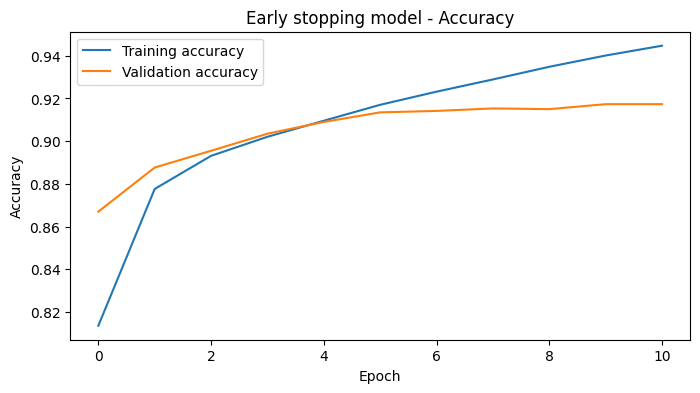

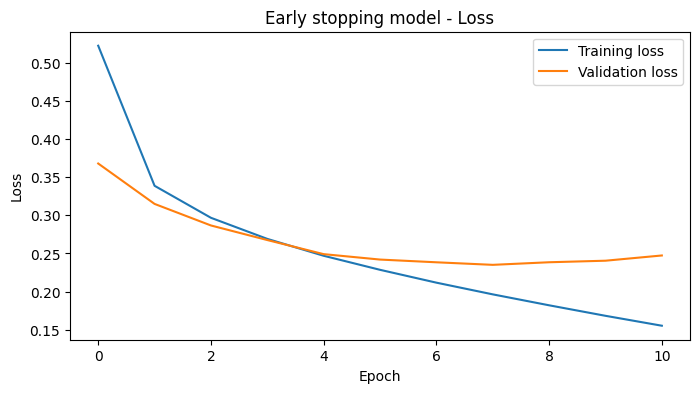

In [ ]:
# Modell med early stopping
# Samma grundstruktur som tidigare modeller, skillnaden är att träningen kommer att avbrytas tidigt om valideringsförlusten inte förbättras under ett antal epoch, vilket kan hjälpa till att förhindra överanpassning.
model_early_stop = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
# Samma learning rate som tidigare modeller, eftersom early stopping inte direkt påverkar hur snabbt modellen lär sig, utan snarare när träningen avbryts baserat på valideringsförlusten.
model_early_stop.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# Early stopping övervakar val_loss och avbryter träningen om den inte förbättras under 3 epoch, samtidigt som den återställer de bästa vikterna som uppnåddes under träningen.
# restore_best_weights=True gör att modellen återställer de vikter som gav den bästa val_loss, vilket kan hjälpa till att få bättre prestanda på testdata även om träningen avbryts tidigt.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# Vi sätter 30 epochs, men early stopping kommer sannolikt att avbryta träningen tidigare om modellen inte förbättras.
history_early_stop = model_early_stop.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data, och för att se vilken effekt early stopping hade på prestanda.
early_stop_test_loss, early_stop_test_accuracy = model_early_stop.evaluate(X_test, y_test)

print("Early stopping test loss:", early_stop_test_loss)
print("Early stopping test accuracy:", early_stop_test_accuracy)
print("Stopped after epoch:", len(history_early_stop.history["loss"]))
# Plottar tränings och valideringskurvor
plot_history(history_early_stop, "Early stopping model")

### Tolkning av Early Stopping reslutat

Early stopping stoppde träningen efter **11 epoker**.

Test accuracy blev ca **0.9063** och test loss ca **0.2698**.

Resultatet visar att modellen inte behövde träna alla 30 epoker. När validation loss slutade förbättras stoppades träningen autmatiskt och modellen återgick till de bästa vikterna.

Detta minskar risken för overfitting, eftersom modellen inte fortsätter träna långt efter att valideringsresultatet slutat förbättras.

### L2-regularisering

L2-regularisering straffar modellen om vikterna blir för stora. Det gör modellen mindre komplex och kan minska risken att den anpassar sig för mycket till träningsdatan.

Vi testar L2 på Dense-lagret.

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8085 - loss: 0.6191 - val_accuracy: 0.8517 - val_loss: 0.4751
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8712 - loss: 0.4228 - val_accuracy: 0.8713 - val_loss: 0.4174
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8869 - loss: 0.3730 - val_accuracy: 0.8782 - val_loss: 0.3852
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8953 - loss: 0.3422 - val_accuracy: 0.8880 - val_loss: 0.3562
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9013 - loss: 0.3203 - val_accuracy: 0.8912 - val_loss: 0.3451
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9063 - loss: 0.3040 - val_accuracy: 0.8960 - val_loss: 0.3346
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9116 - loss: 0.2911 - val_accuracy: 0.9002 - val_loss: 0.3239
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9153 - loss: 0.2806 - val_accuracy: 0.

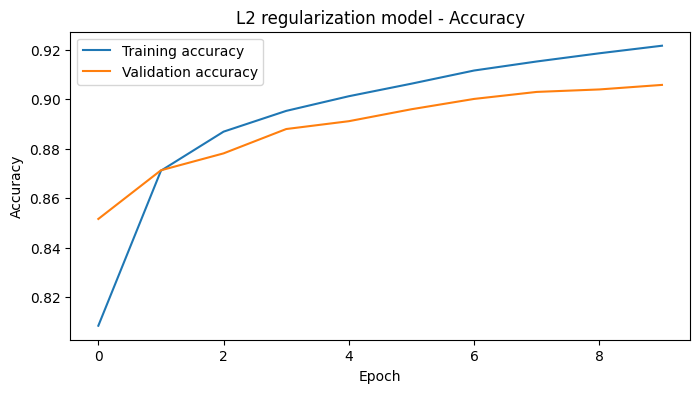

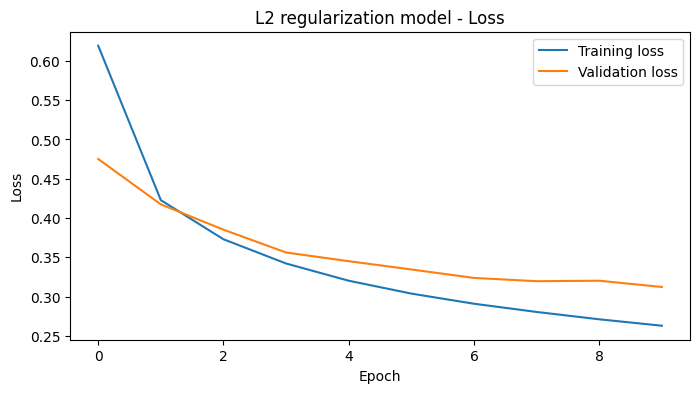

In [ ]:
# Modell med L2-regularisering
# L2 läggs på Dense-lagret för att straffa stora vikter, vilket kan hjälpa till att förhindra överanpassning genom att hålla vikterna små.
model_l2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation="softmax")
])
# Samma learning rate som i överiga modeller, eftersom L2-regularisering inte direkt påverkar hur snabbt modellen lär sig, utan snarare straffar stora vikter under träningen.
model_l2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# Vi tränar modellen och använder samma antal epoch och batch size som tidigare modeller för att göra resultaten mer jämförbara.
history_l2 = model_l2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)
# Vi utvärderar modellen på testdata för att se hur väl den generaliserar till helt nya data.
l2_test_loss, l2_test_accuracy = model_l2.evaluate(X_test, y_test)

print("L2 regularization test loss:", l2_test_loss)
print("L2 regularization test accuracy:", l2_test_accuracy)
# Plottar tränings och valideringskurvor
plot_history(history_l2, "L2 regularization model")

### Tolking av L2 resultat

L2-regularisering gav en test accuracy på ca **0.8882** och test loss på ca **0.3493**.

Training accuracy ökade långsammare än i modellerna utan regularisering, vilket är förväntat eftersom L2 begränsar modellens vikter.

I vårt fall gav L2 lägre test accuracy än både Dropout och Early Stopping. Det kan tyda på att L2 styrkan var något för hård eller att just denna modell inte hade lika stor nytta av L2 som av Dropout.

L2 är ändå relevant eftersom den visar hur man kan minska modellens komplexitet genom att då straffa stora vikter.

## Extra experiment: olika Dropout-nivåer

För att fördjupa oss lite mer testar vi flera nivåer av Dropout. Syftet är att ser hur styrkan på regulariseringen påverkar modellens resultat och generalisering.

Vi testar:
- Dropout 0.1
- Dropout 0.3
- Dropout 0.5

En låg dropout kan ge för svag regularisering, medan en för hög dropout kan göra att modellen får svårt att lära sig tillräckligt mycket.

In [ ]:
# Funktion som bygger en modell med valfri dropout rate

def build_dropout_model(dropout_rate):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#Lista för att spara resultaten av olika dropout rates
dropout_experiments = []

# Testar flera dropout rates
for rate in [0.1, 0.3, 0.5]:
    print(f"Training model with dropout rate: {rate}")
    model_temp = build_dropout_model(rate)
    history_temp = model_temp.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val)
    )
    # Utvärderar modellen på testdata och sparar resultaten i listan
    test_loss, test_accuracy = model_temp.evaluate(X_test, y_test)
    dropout_experiments.append({
        "Dropout rate": rate,
        "Test loss": test_loss,
        "Test accuracy": test_accuracy,
        "Final train accuracy": history_temp.history["accuracy"][-1],
        "Final val accuracy": history_temp.history["val_accuracy"][-1],
        "Final train loss": history_temp.history["loss"][-1],
        "Final val loss": history_temp.history["val_loss"][-1]
    })
# Skapar en DataFrame för att jämföra resultaten av olika dropout rates
dropout_experiments_df = pd.DataFrame(dropout_experiments)
dropout_experiments_df.sort_values("Test accuracy", ascending=False)

Training model with dropout rate: 0.1
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8008 - loss: 0.5557 - val_accuracy: 0.8680 - val_loss: 0.3660
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8722 - loss: 0.3574 - val_accuracy: 0.8910 - val_loss: 0.3072
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8873 - loss: 0.3118 - val_accuracy: 0.8985 - val_loss: 0.2802
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8975 - loss: 0.2818 - val_accuracy: 0.9097 - val_loss: 0.2541
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9050 - loss: 0.2578 - val_accuracy: 0.9093 - val_loss: 0.2507
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9113 - loss: 0.2393 - val_accuracy: 0.9090 - val_loss: 0.2444
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9178 - loss: 0.2235 - val_accuracy: 0.9142 - val_loss: 0.2381
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.

,Dropout rate,Test loss,Test accuracy,Final train accuracy,Final val accuracy,Final train loss,Final val loss
0,0.1,0.249303,0.9107,0.931556,0.921167,0.181903,0.218138
2,0.5,0.260322,0.9072,0.895463,0.920167,0.292480,0.226768
1,0.3,0.256912,0.9047,0.914833,0.918333,0.235907,0.225424


### Tolkning av olika Dropout-nivåer

Vi testade flera nivåer av dropout för att undersöka hur styrkan på reguliseringen påverkar modellens prestanda.

Resultaten visade att Dropout 0.1 gav högst test accuracy (0.9107) och lägst test loss (0.2493).

När Dropout ökades till 0.3 och 0.5 sjönk test accuracy, medan test loss ökade.

Det tyder på att för stark regularisering kan göra att modellen får svårare att lära sig viktigt mönster från träningsdatan med högre Dropout vikter.

Samtidigt är syftet med Dropout inte bara att maximera training accuracy utan att förbättra generalisering och minska risken för overfitting.

I vårt fall verkar en lägre Dropout-nivå fungera bästa för just denna modell och datamängd.

Det viktigaste att ta från detta experiment är att regularisering behöver balanseras. För lite regularisering kan ge overfitting medan för mycket regularisering kan göra modellen svagare.

## Slutlig jämförelse

Här jämför vi baseline, tidigare modellförändringar och regulariseringsmetoderna.

In [26]:
# Skapar en tabell som sammanfattar resultaten från alla experiment, inklusive baseline, de olika modellerna vi testat & resultaten från dropout-experimentet.
final_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dense 128",
        "More filters",
        "Lower learning rate",
        "Dropout (original)",
        "Early stopping",
        "L2 regularization"
    ],
    "Test loss": [
        baseline_test_loss,
        dense_128_test_loss,
        more_filters_test_loss,
        lower_lr_test_loss,
        dropout_test_loss,
        early_stop_test_loss,
        l2_test_loss
    ],
    "Test accuracy": [
        baseline_test_accuracy,
        dense_128_test_accuracy,
        more_filters_test_accuracy,
        lower_lr_test_accuracy,
        dropout_test_accuracy,
        early_stop_test_accuracy,
        l2_test_accuracy
    ]
})

# Omstrukturera dropout-resultaten för att passa in i tabellen
dropout_results_for_table = dropout_experiments_df.rename(columns={
    "Dropout rate": "Model",
    "Test loss": "Test loss",
    "Test accuracy": "Test accuracy"
})[["Model", "Test loss", "Test accuracy"]]

dropout_results_for_table["Model"] = dropout_results_for_table["Model"].apply(
    lambda x: f"Dropout {x}"
)

# Lägg till resultaten från extra dropout-experimentet i tabellen
final_results = pd.concat(
    [final_results, dropout_results_for_table],
    ignore_index=True
)
# Kombinera alla resultat i en tabell och sortera efter test accuracy för att se vilka modeller som presterade bäst.
final_results.sort_values("Test accuracy", ascending=False)

,Model,Test loss,Test accuracy
4,Dropout (original),0.245890,0.9116
7,Dropout 0.1,0.249303,0.9107
1,Dense 128,0.338473,0.9095
9,Dropout 0.5,0.260322,0.9072
3,Lower learning rate,0.272283,0.9071
5,Early stopping,0.269814,0.9063
2,More filters,0.338595,0.9061
8,Dropout 0.3,0.256912,0.9047
6,L2 regularization,0.349346,0.8882
0,Baseline,0.563906,0.8784


### Tolkning av slutlig jämförelse

Den slutliga jämförelsen visar att flera förändringar i modellen påverkar resultatet på olika sätt.

Den högsta test accuracy uppnåddes av den första Dropout-modellen (0.9116), följt av Dropout 0.1 (0.9107). Detta visar tydligt att regularisering kan förbättra modellens generalisering.

Experimentet med olika dropout-nivåer visade också att starkare regularisering inte automatiskt ger bättre resultat. Detta då Dropout 0.1 presterade bättre än både Dropout 0.3 och 0.5.

Lower learning rate gav också ett stabilt resultat (0.9071), vilket tyder på att en långsammare inlärning hjälpte modellen att lära sig mer stabilt.

Early stopping gav liknande resultat (0.9063) och visade hur träningen kan stoppas innan modellen börjar överanpassa sig.

L2-regularisering gav lägst resultat av alla regulariseringsmetoderna i vårt test (0.8882), vilket visar tecken på att denna metod inte passade lika bra för vår modell och våra parametrar.

Resultaten visar att regularisering behöver anpassas efter modellen. För stark regularisering förbättrar inte alltid generalisering och olika metoder kan påverka modellen på olika sätt.

## Slutsats

I den här uppgiften fördjupade vi oss i regularisering och hur det påverkar en CNN-modell på Fashion MNIST.

Vi testade Dropout, Early stopping & L2-regularisering. Vi testade dessutom flera olika Dropout nivåer för att se hur stark regularisering kan påverka resultatet.

Resultatet visade att Dropout fungerade bästa av alla metoder vi använde i vårt projekt. Den hjälpte modellen att generalisera bättre utan att försämra test accuracy.

Samtidigt visade Early stopping också oss varför validation loss är viktigt. Modellen stoppades automatiskt när valideringsresultatet slutade förbättras.

L2-regularisering gav lägre test accuracy i vårt test men är fortfarande en viktigt metod att kunna använda eftersom den begränsar modellens vikter och kan minska överanpassning i vissa fall.

Den viktigaste lärdomen är att hög training accuracy inte alltid betyder att modellen är bäst. En bra Deep Learning-modell måste också kunna generalisera bra till ny data.

Regularisering handlar därför mest om en balans. Modellen ska vara tillräckligt stark för att lära sig mönster, men inte så flexibel att den bara memorerar träningsdatan.